# Mô phỏng chỉ số VN30

Notebook này thực hiện việc lọc các mã cổ phiếu thuộc rổ VN30 và tính toán biến động luỹ kế dựa trên phương pháp trọng số đều (Equal-Weight) để mô phỏng biểu đồ của VN30. Do không có sẵn dữ liệu khối lượng lưu hành (shares outstanding) để tính vốn hoá thị trường chính xác, phương pháp Equal-Weight (trung bình đều) cung cấp một mô phỏng tương đối và trực quan đánh giá nhóm VN30.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# 1. Đọc danh sách mã VN30
with open('../market_lists/vn30.txt', 'r') as f:
    vn30_tickers = [line.strip() for line in f.readlines() if line.strip()]

print(f"Số lượng mã VN30 tải được: {len(vn30_tickers)}")
print("Danh sách:", vn30_tickers)

Số lượng mã VN30 tải được: 30
Danh sách: ['ACB', 'BID', 'CTG', 'DGC', 'FPT', 'GAS', 'GVR', 'HDB', 'HPG', 'LPB', 'MBB', 'MSN', 'MWG', 'PLX', 'SAB', 'SHB', 'SSB', 'SSI', 'STB', 'TCB', 'TPB', 'VCB', 'VHM', 'VIB', 'VIC', 'VJC', 'VNM', 'VPB', 'VPL', 'VRE']


In [3]:
# 2. Tải dữ liệu lịch sử và lọc VN30
data_path = '../data/processed/assets/data_info_vn/history/vn_gold_recommended.csv'
cols = ['Date', 'code', 'intraday_return']
df = pd.read_csv(data_path, usecols=cols)

# Chuyển Date sang chuẩn datetime
df['Date'] = pd.to_datetime(df['Date'])

# Lọc các mã trong rổ VN30
vn30_df = df[df['code'].isin(vn30_tickers)].copy()
vn30_df.dropna(subset=['intraday_return'], inplace=True)
print("Dữ liệu VN30 tải về thành công, kích thước:", vn30_df.shape)

Dữ liệu VN30 tải về thành công, kích thước: (80830, 3)


In [4]:
# 3. Tính toán Index Mô phỏng (Equal-Weight)
# Tính trung bình tỷ suất sinh lời của rổ VN30 trong mỗi ngày
vn30_daily = vn30_df.groupby('Date').agg(
    daily_return=('intraday_return', 'mean'),
    stock_count=('code', 'count')
).reset_index()

# Tính lợi nhuận luỹ kế (Cumulative Return)
# Giả định điểm bắt đầu là giá trị 1000
vn30_daily['cum_return'] = (1 + vn30_daily['daily_return']).cumprod()
vn30_daily['simulated_index'] = 1000 * vn30_daily['cum_return']

vn30_daily.set_index('Date', inplace=True)
display(vn30_daily.head())

,daily_return,stock_count,cum_return,simulated_index
Date,,,,
2012-03-20,0.012687,11,1.012687,1012.686734
2012-03-21,0.005579,11,1.018336,1018.336255
2012-03-22,-0.000149,11,1.018184,1018.184147
2012-03-23,0.011784,11,1.030182,1030.182110
2012-03-26,-0.008878,12,1.021036,1021.036329


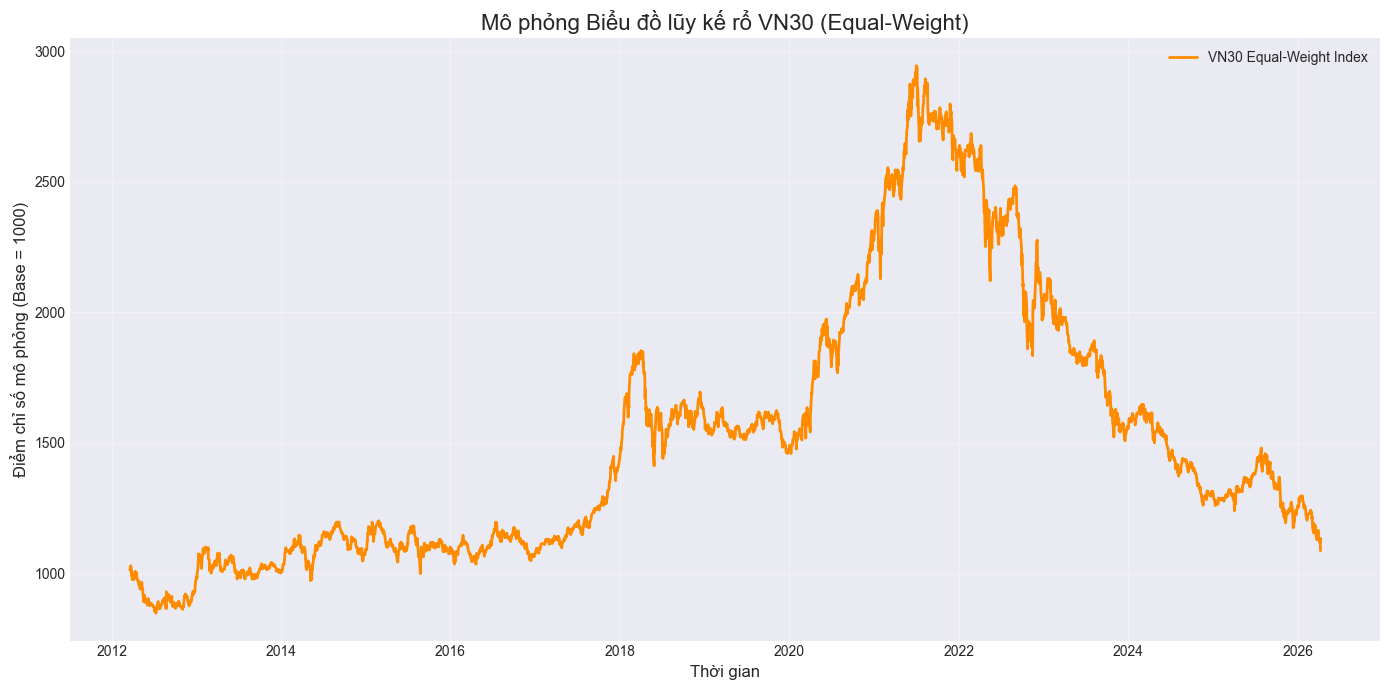

In [5]:
# 4. Vẽ biểu đồ
plt.figure(figsize=(14, 7))
plt.plot(vn30_daily.index, vn30_daily['simulated_index'], label='VN30 Equal-Weight Index', color='darkorange', linewidth=2)
plt.title('Mô phỏng Biểu đồ lũy kế rổ VN30 (Equal-Weight)', fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Điểm chỉ số mô phỏng (Base = 1000)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()